Implement the full SVD from scratch without using power iteration. Instead, compute the eigendecomposition of A^T A to get V and the singular values, then compute U = A V Sigma^{-1}. Compare numerical accuracy with your power iteration version and with NumPy.

In [1]:
import numpy as np
def svd_from_eigen(A,tol=1e-10):
    m,n=A.shape
    ATA=A.T @ A
    eigenvalues,eigenvectors=np.linalg.eigh(ATA)
    idx=np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    V = eigenvectors[:, idx]
    eigenvalues = np.maximum(eigenvalues, 0)
    singular_values = np.sqrt(eigenvalues)
    rank = np.sum(singular_values > tol)
    S = singular_values[:rank]
    V = V[:, :rank]
    U = (A @ V) / S

    return U, S, V.T

In [2]:
A = np.array([
    [1, 1],
    [2, 1],
    [3, 1]
], dtype=float)

In [4]:
U, S, Vt = svd_from_eigen(A)

print("U:")
print(U)

print("\nS:")
print(S)

print("\nVt:")
print(Vt)

U:
[[-0.32310986 -0.85377594]
 [-0.54750702 -0.18321952]
 [-0.77190419  0.4873369 ]]

S:
[4.07914333 0.60049122]

Vt:
[[-0.91534819 -0.40266324]
 [ 0.40266324 -0.91534819]]


In [5]:
A_reconstructed = U @ np.diag(S) @ Vt

print("\nOriginal A:")
print(A)

print("\nReconstructed A:")
print(A_reconstructed)


Original A:
[[1. 1.]
 [2. 1.]
 [3. 1.]]

Reconstructed A:
[[1. 1.]
 [2. 1.]
 [3. 1.]]


In [6]:
# NumPy SVD
U_np, S_np, Vt_np = np.linalg.svd(
    A,
    full_matrices=False
)

# Our SVD
U_eig, S_eig, Vt_eig = svd_from_eigen(A)

print("Our singular values:")
print(S_eig)

print("\nNumPy singular values:")
print(S_np)

Our singular values:
[4.07914333 0.60049122]

NumPy singular values:
[4.07914333 0.60049122]


Load a real grayscale image (or convert one to grayscale). Compress it at ranks 1, 5, 10, 25, 50, 100. For each rank, compute the compression ratio and the relative error. Find the rank where the image becomes visually acceptable.

Rank  1 | Compression ratio: 13.75x | Relative error: 0.3955
Rank  5 | Compression ratio: 2.75x | Relative error: 0.1268
Rank 10 | Compression ratio: 1.38x | Relative error: 0.0623
Rank 20 | Compression ratio: 0.69x | Relative error: 0.0067
Rank 28 | Compression ratio: 0.49x | Relative error: 0.0000


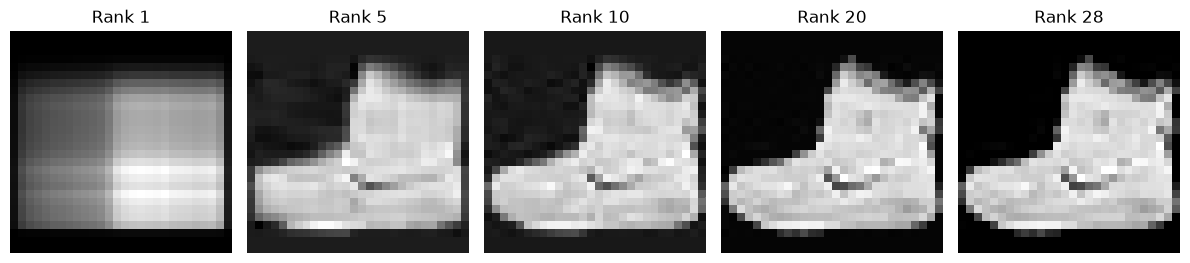

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Load Fashion-MNIST
data = fetch_openml("Fashion-MNIST", version=1, as_frame=False)

X = data.data.astype(float)

# Take one image and reshape to 28x28
image = X[0].reshape(28, 28)

# SVD
U, S, Vt = np.linalg.svd(image, full_matrices=False)

ranks = [1, 5, 10, 20, 28]

plt.figure(figsize=(12, 6))

for i, r in enumerate(ranks):

    # Reconstruct using only r singular values
    compressed = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :]

    # Relative reconstruction error
    error = np.linalg.norm(image - compressed) / np.linalg.norm(image)

    # Compression ratio
    original_params = 28 * 28
    compressed_params = r * (28 + 1 + 28)

    ratio = original_params / compressed_params

    print(
        f"Rank {r:2d} | "
        f"Compression ratio: {ratio:.2f}x | "
        f"Relative error: {error:.4f}"
    )

    # Plot
    plt.subplot(1, len(ranks), i + 1)

    plt.imshow(compressed, cmap="gray")
    plt.title(f"Rank {r}")
    plt.axis("off")

plt.tight_layout()
plt.show()